# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


**Latar Belakang Dataset**

Dataset Bank Marketing merupakan kumpulan data hasil kampanye pemasaran langsung (direct marketing) yang dilakukan oleh sebuah institusi perbankan di Portugal. Kampanye pemasaran dilakukan melalui panggilan telepon (telemarketing) dengan tujuan menawarkan produk deposito berjangka (term deposit) kepada nasabah.

Setiap baris data merepresentasikan satu orang nasabah beserta karakteristik demografis, kondisi finansial, riwayat kontak pemasaran, dan hasil kampanye sebelumnya. Variabel target (y) menunjukkan apakah nasabah akhirnya berlangganan deposito berjangka (yes) atau tidak (no).

Dataset ini banyak digunakan sebagai benchmark pada penelitian machine learning karena memiliki kombinasi fitur numerik dan kategorikal yang beragam, sehingga sangat cocok digunakan untuk proses eksplorasi data, preprocessing, pelatihan model klasifikasi, hingga evaluasi performa model.

**Informasi Dataset**
* Nama Dataset    : Bank Marketing Dataset
* Sumber          : UCI Machine Learning Repository
* Jumlah Data     : 45.211 baris
* Jumlah Fitur	  : 17 kolom
* Target	        : y
* Jenis Masalah	  : Binary Classification

**Tujuan Analisis**
Tujuan dari eksperimen ini adalah membangun model machine learning yang mampu memprediksi apakah seorang nasabah akan berlangganan deposito berjangka berdasarkan informasi karakteristik pribadi, kondisi finansial, dan riwayat interaksi dengan pihak bank.

Model yang dihasilkan diharapkan dapat membantu pihak bank mengidentifikasi calon nasabah potensial sehingga strategi pemasaran dapat dilakukan secara lebih efektif dan efisien.

**Alasan Memilih Dataset**

Dataset Bank Marketing dipilih karena memiliki jumlah data yang besar, kualitas data yang baik, serta mencakup berbagai jenis fitur numerik dan kategorikal yang sesuai untuk mempelajari proses preprocessing dan klasifikasi. Selain itu, dataset ini merupakan salah satu dataset standar yang sering digunakan dalam penelitian maupun pembelajaran machine learning sehingga hasil eksperimen dapat dibandingkan dengan penelitian lain.

**Sumber Dataset**

Dataset diperoleh dari **UCI Machine Learning Repository**.

Link:
https://archive.ics.uci.edu/dataset/222/bank+marketing

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [60]:
# Manipulasi Data
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Split Data
from sklearn.model_selection import train_test_split

# Pengaturan Tampilan
pd.set_option('display.max_columns', None)

# Menghilangkan warning
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

Dataset dibaca menggunakan pustaka **Pandas** dengan fungsi `read_csv()`. Dataset yang digunakan adalah **Bank Marketing Dataset** yang disimpan pada Google Drive sehingga perlu dilakukan proses mounting terlebih dahulu sebelum data dapat diakses.

In [61]:
url = "https://raw.githubusercontent.com/Mohalfinoor/Eksperimen_SML_MohalfinoorWirabuana/main/bank-full.csv"

df = pd.read_csv(url, sep=";")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [62]:
# Menampilkan dimensi dataset

print(f"Jumlah baris : {df.shape[0]}")
print(f"Jumlah kolom : {df.shape[1]}")

Jumlah baris : 45211
Jumlah kolom : 17


In [63]:
# Informasi dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [64]:
# Statistik deskriptif

df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [65]:
# Statistik seluruh kolom

df.describe(include="all")

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,45211.000000,45211,45211,45211,45211,45211.000000,45211,45211,45211,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,45211,45211
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,9732,27214,23202,44396,NaN,25130,37967,29285,NaN,13766,NaN,NaN,NaN,NaN,36959,39922
mean,40.936210,NaN,NaN,NaN,NaN,1362.272058,NaN,NaN,NaN,15.806419,NaN,258.163080,2.763841,40.197828,0.580323,NaN,NaN
std,10.618762,NaN,NaN,NaN,NaN,3044.765829,NaN,NaN,NaN,8.322476,NaN,257.527812,3.098021,100.128746,2.303441,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,448.000000,NaN,NaN,NaN,16.000000,NaN,180.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1428.000000,NaN,NaN,NaN,21.000000,NaN,319.000000,3.000000,-1.000000,0.000000,NaN,NaN


In [66]:
# Menampilkan nama seluruh kolom

df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [67]:
# Menampilkan lima data terakhir

df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

### 4.1 Menampilkan Sampel Data

Langkah pertama adalah melihat beberapa sampel data secara acak untuk memahami struktur dataset dan memastikan data telah dimuat dengan benar.

In [68]:
df.sample(5, random_state=42)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
3776,40,blue-collar,married,secondary,no,580,yes,no,unknown,16,may,192,1,-1,0,unknown,no
9928,47,services,single,secondary,no,3644,no,no,unknown,9,jun,83,2,-1,0,unknown,no
33409,25,student,single,tertiary,no,538,yes,no,cellular,20,apr,226,1,-1,0,unknown,no
31885,42,management,married,tertiary,no,1773,no,no,cellular,9,apr,311,1,336,1,failure,no
15738,56,management,married,tertiary,no,217,no,yes,cellular,21,jul,121,2,-1,0,unknown,no


### 4.2 Pemeriksaan Missing Value

Pemeriksaan missing value dilakukan untuk mengetahui apakah terdapat nilai kosong yang perlu ditangani sebelum proses pemodelan.

In [69]:
missing = df.isnull().sum()

missing

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


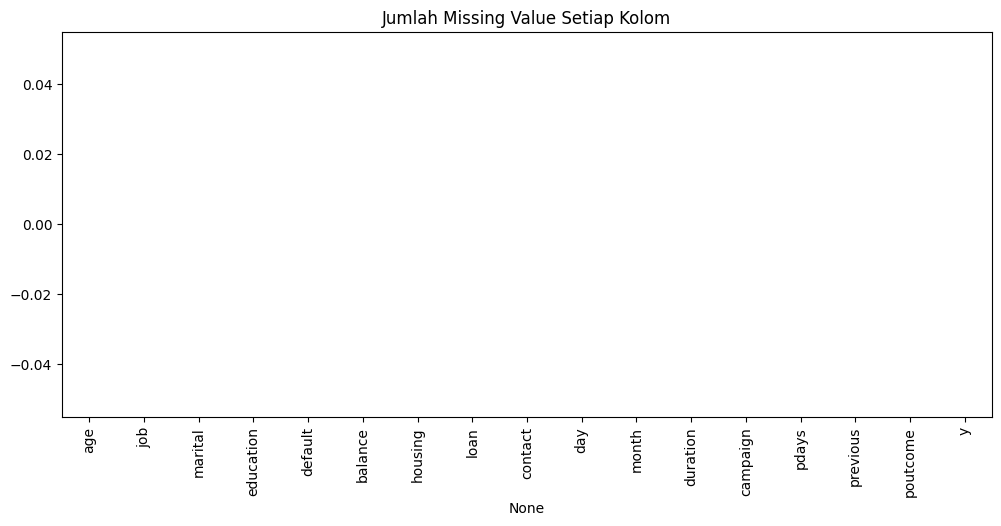

In [70]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=missing.index,
    y=missing.values
)

plt.xticks(rotation=90)

plt.title("Jumlah Missing Value Setiap Kolom")

plt.show()

### Analisis Missing Value

Berdasarkan hasil pemeriksaan, seluruh kolom memiliki nilai missing sebesar 0. Hal ini menunjukkan bahwa dataset sudah lengkap sehingga tidak diperlukan proses imputasi pada tahap preprocessing.

### 4.3 Pemeriksaan Data Duplikat

Selanjutnya dilakukan pengecekan terhadap data duplikat untuk mengetahui apakah terdapat observasi yang tercatat lebih dari satu kali.

In [71]:
duplicate = df.duplicated().sum()

print(f"Jumlah data duplikat : {duplicate}")

Jumlah data duplikat : 0


### Analisis Data Duplikat

Hasil pemeriksaan menunjukkan bahwa dataset memiliki **...** data duplikat.

Data duplikat akan dihapus pada tahap preprocessing agar setiap observasi hanya muncul satu kali dan tidak menyebabkan bias pada proses pelatihan model.

### 4.4 Distribusi Variabel Target

Analisis distribusi target dilakukan untuk mengetahui keseimbangan jumlah kelas pada variabel target (`y`).

In [72]:
df["y"].value_counts()

,count
y,
no,39922
yes,5289


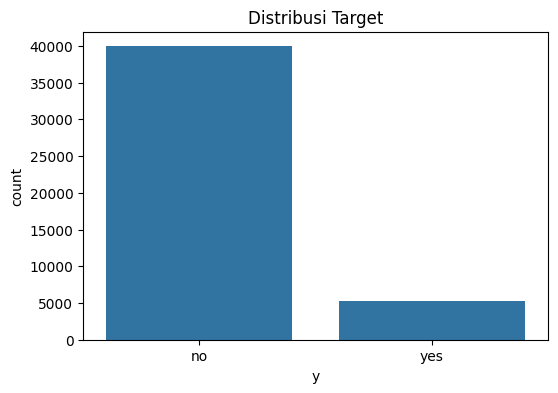

In [73]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="y"
)

plt.title("Distribusi Target")

plt.show()

In [74]:
(df["y"].value_counts(normalize=True)*100).round(2)

,proportion
y,
no,88.3
yes,11.7


### Analisis Distribusi Target

Distribusi target menunjukkan bahwa kelas **no** lebih dominan dibandingkan kelas **yes**.

Hal ini menunjukkan adanya ketidakseimbangan kelas (class imbalance) sehingga perlu diperhatikan pada saat pembangunan model machine learning.

### 4.5 Distribusi Fitur Numerik

Visualisasi distribusi fitur numerik digunakan untuk memahami pola sebaran data, kemencengan distribusi (skewness), serta indikasi adanya outlier.

In [75]:
numerical = df.select_dtypes(include=["int64","float64"])

numerical.columns

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

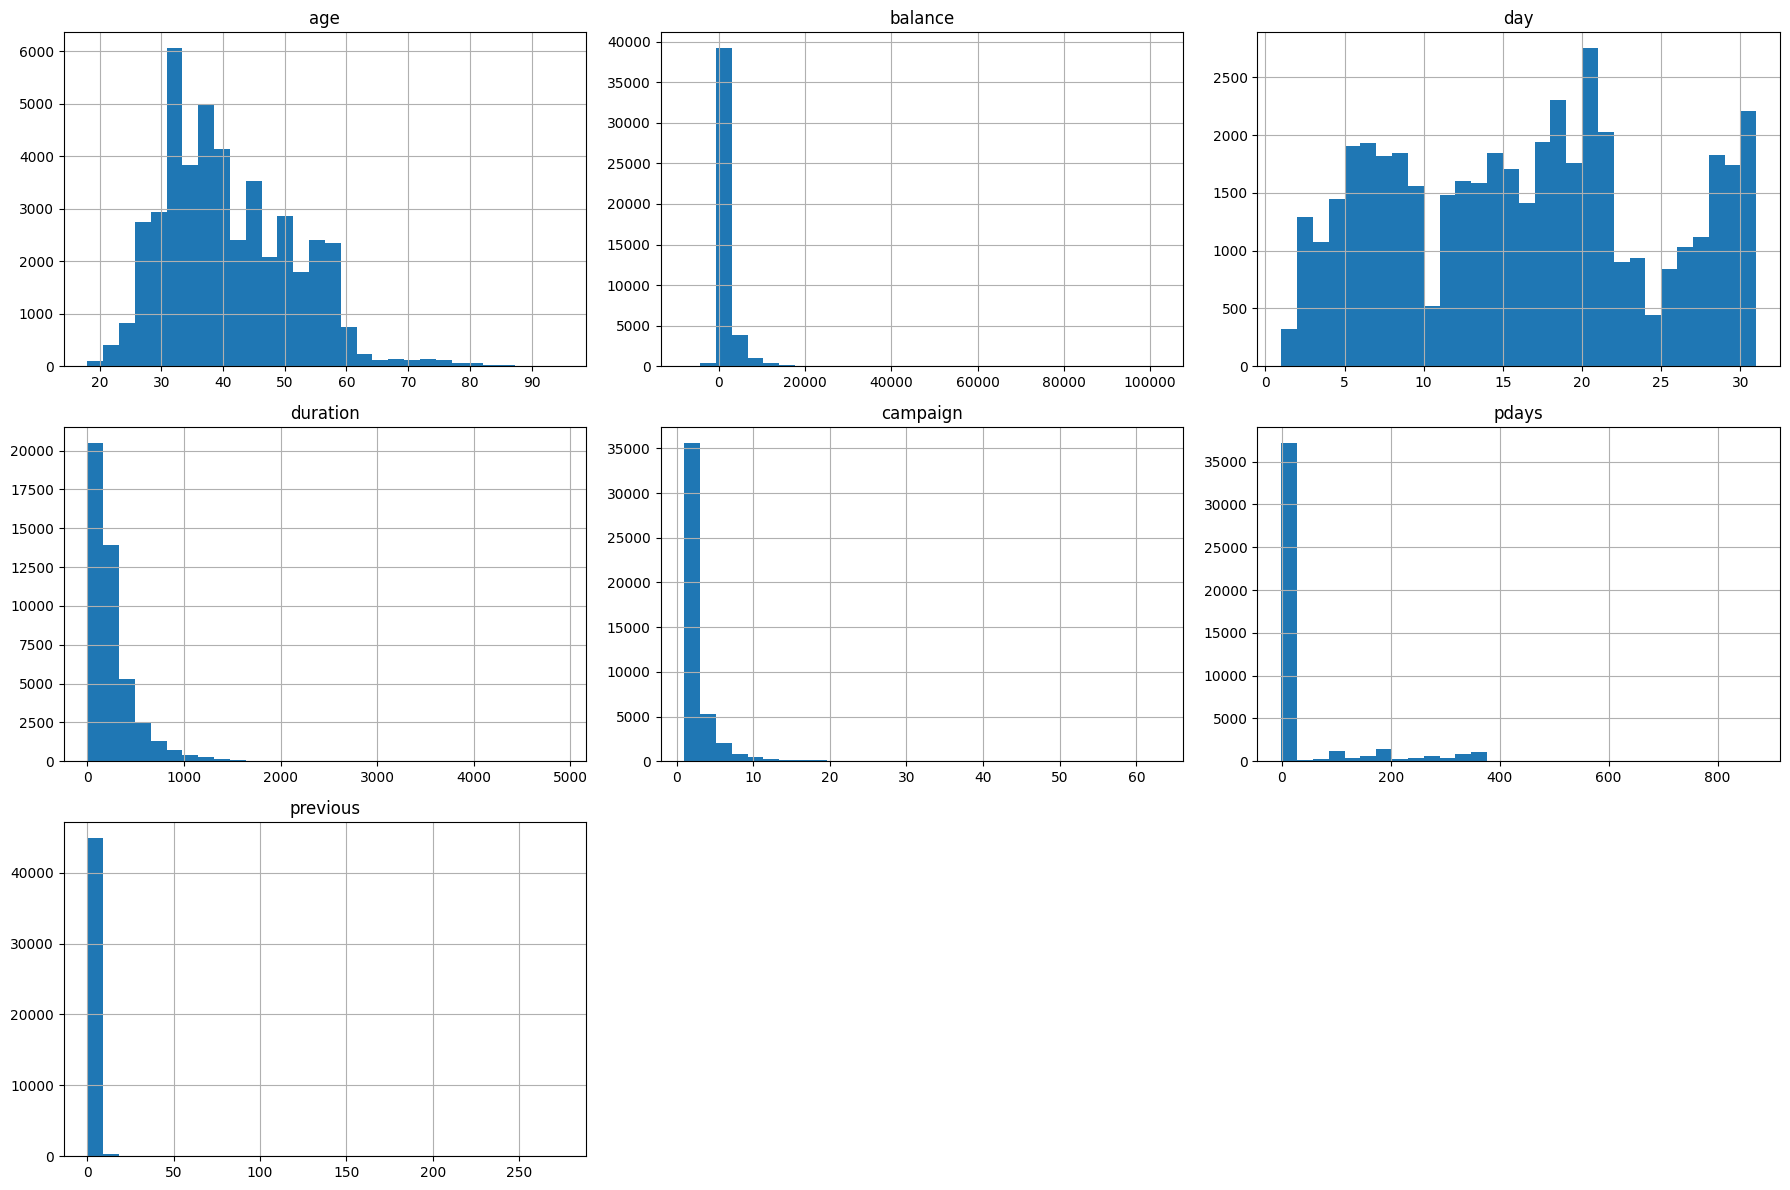

In [76]:
numerical.hist(
    figsize=(18,12),
    bins=30
)

plt.tight_layout()

plt.show()

### Analisis Distribusi Fitur Numerik

Sebagian besar fitur numerik memiliki distribusi yang tidak simetris (skewed). Selain itu terlihat beberapa fitur memiliki rentang nilai yang cukup jauh sehingga standarisasi akan dilakukan pada tahap preprocessing.

### 4.6 Distribusi Fitur Kategorikal

Distribusi variabel kategorikal dianalisis untuk mengetahui proporsi masing-masing kategori pada setiap fitur.

In [77]:
categorical = df.select_dtypes(include="object")

categorical.columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')

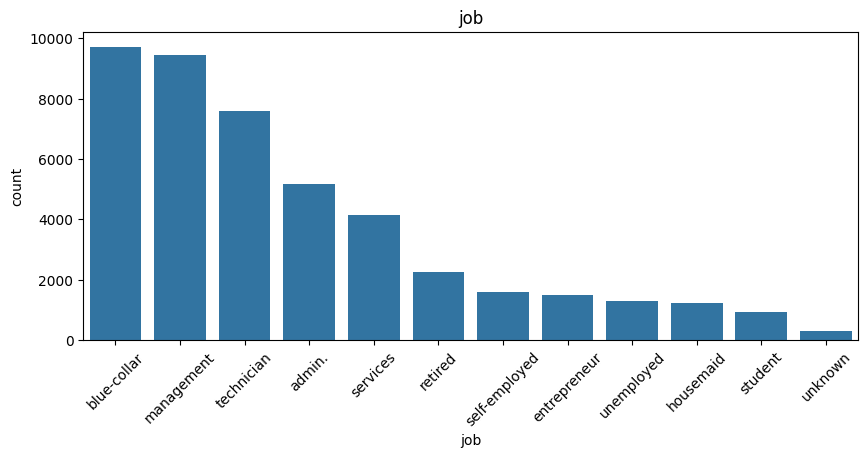

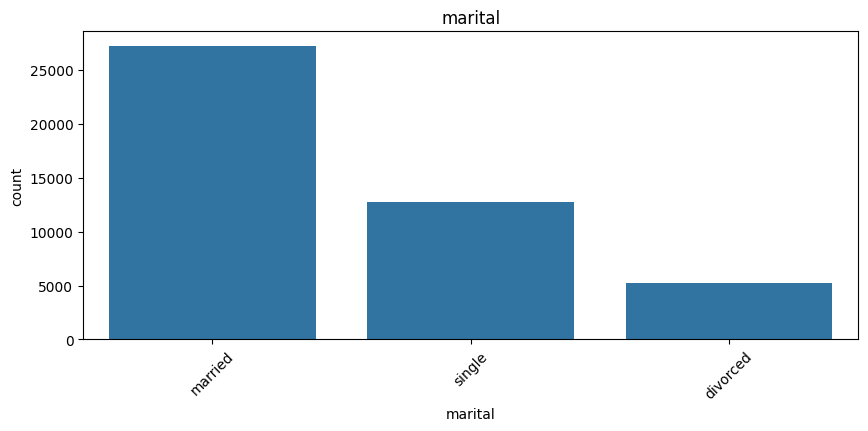

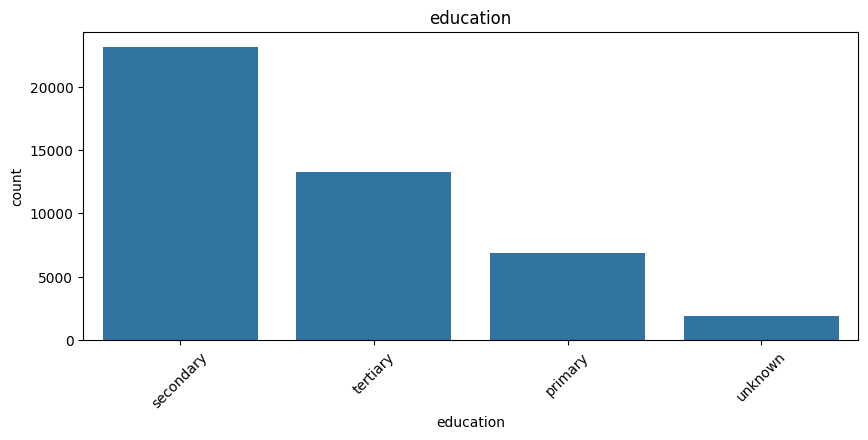

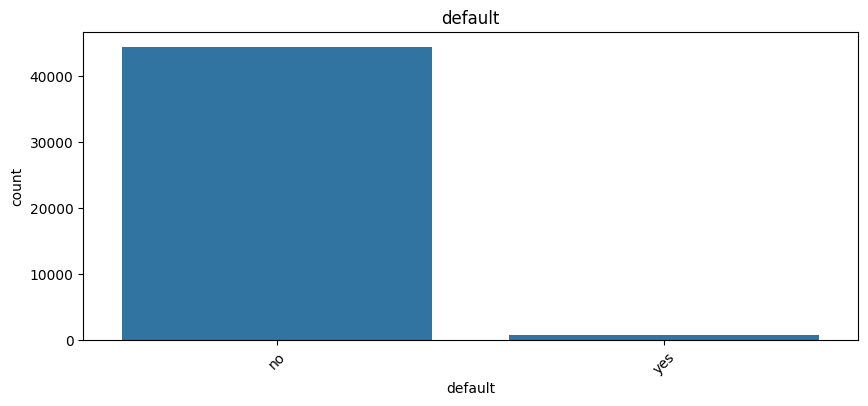

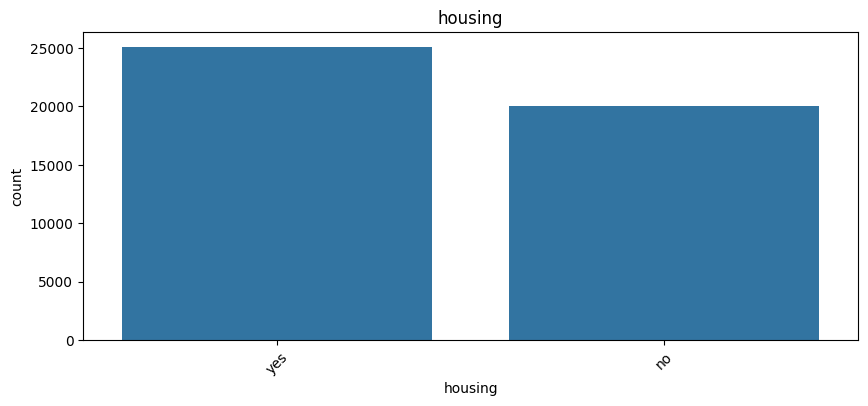

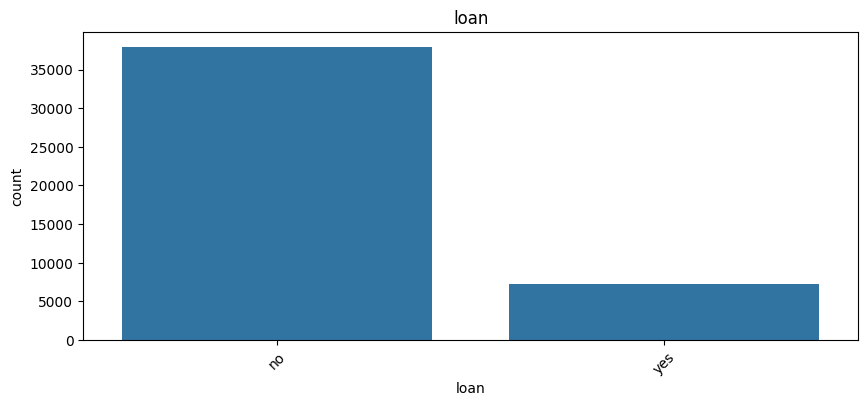

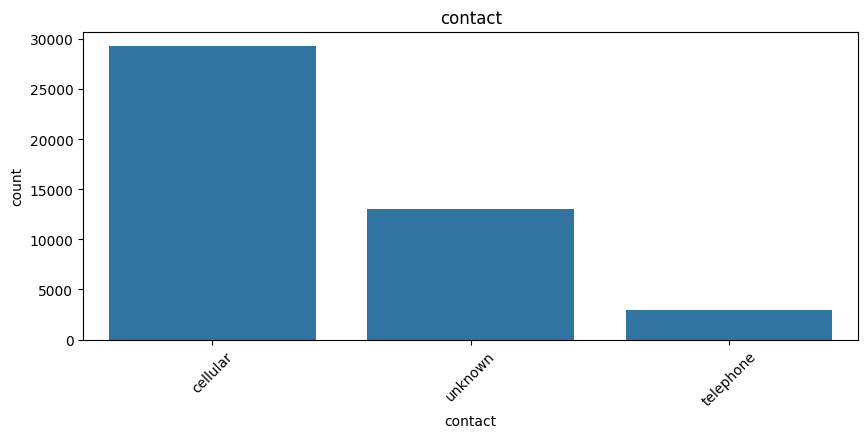

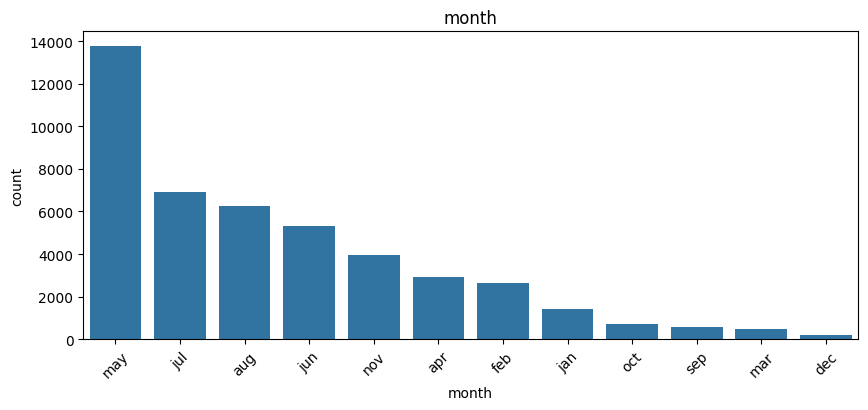

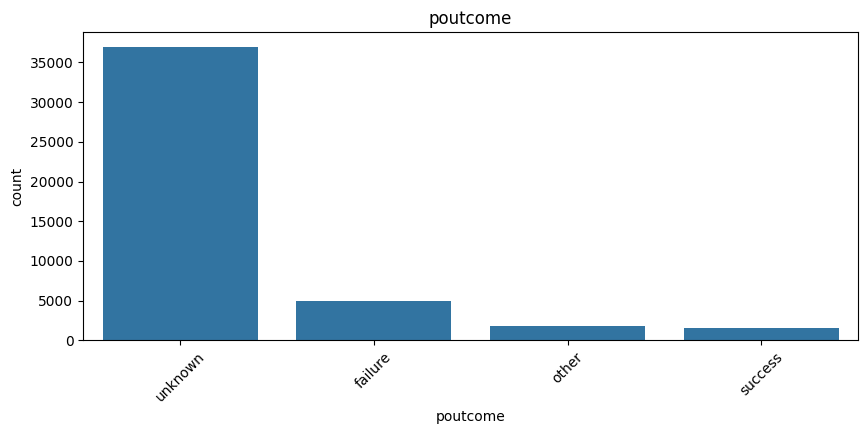

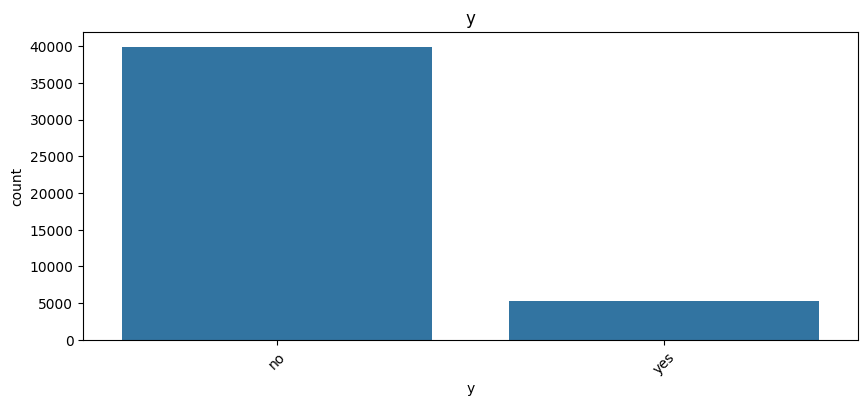

In [78]:
for col in categorical.columns:

    plt.figure(figsize=(10,4))

    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )

    plt.xticks(rotation=45)

    plt.title(col)

    plt.show()

### Analisis Distribusi Fitur Kategorikal

Dataset memiliki beberapa fitur kategorikal seperti pekerjaan, status pernikahan, pendidikan, jenis kontak, dan bulan.

Karena sebagian besar fitur tersebut bersifat nominal dan tidak memiliki urutan, maka teknik One-Hot Encoding akan digunakan pada tahap preprocessing.

### 4.7 Analisis Korelasi

Heatmap korelasi digunakan untuk melihat hubungan antar fitur numerik dalam dataset.

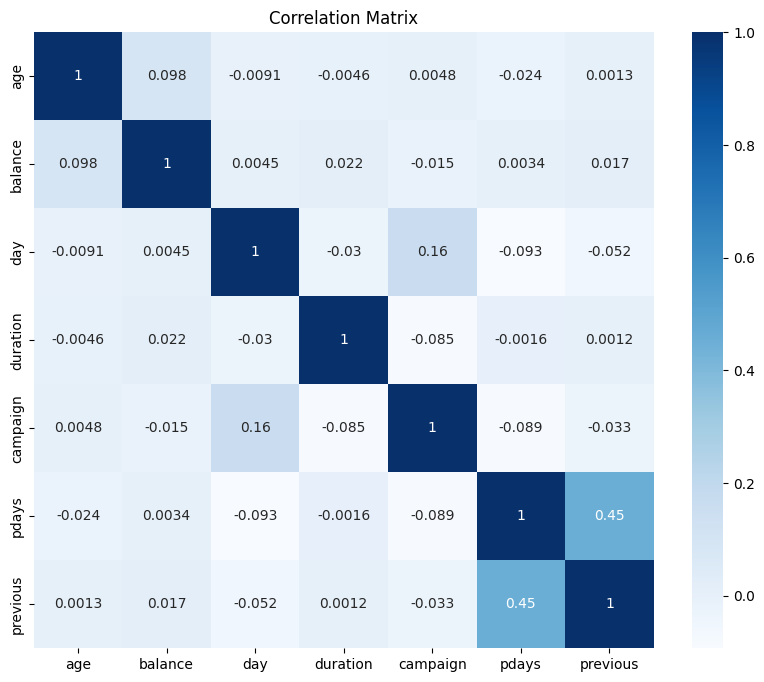

In [79]:
plt.figure(figsize=(10,8))

sns.heatmap(
    numerical.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")

plt.show()

### Analisis Korelasi

Berdasarkan heatmap korelasi, tidak terdapat korelasi yang sangat tinggi antar fitur numerik.

Hal ini menunjukkan bahwa risiko multikolinearitas relatif rendah sehingga seluruh fitur numerik masih dapat digunakan dalam proses pemodelan.

### 4.8 Identifikasi Outlier

Boxplot digunakan untuk mengidentifikasi kemungkinan adanya outlier pada setiap fitur numerik.

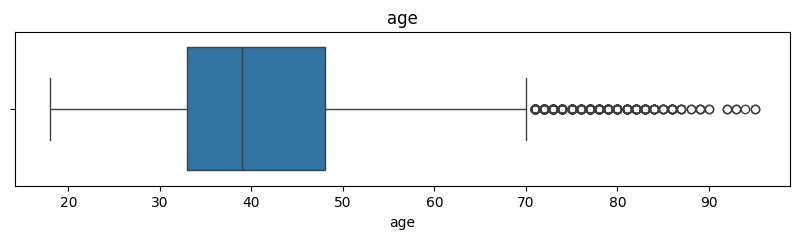

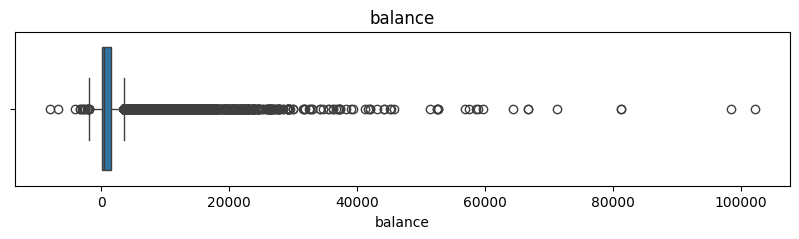

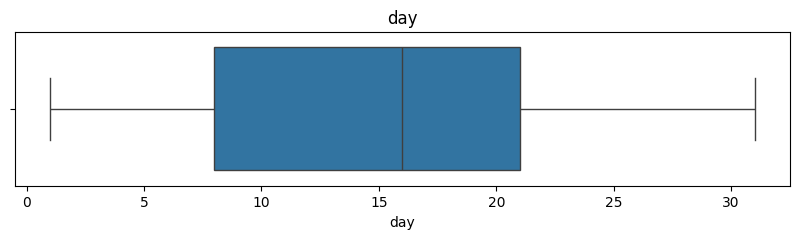

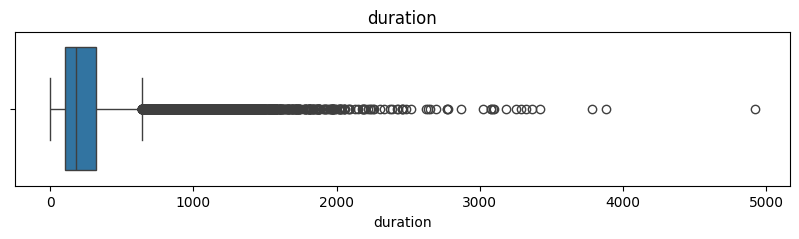

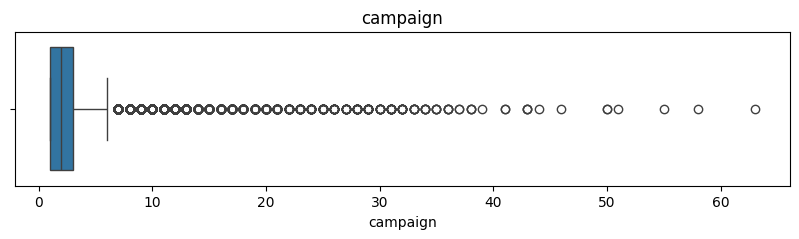

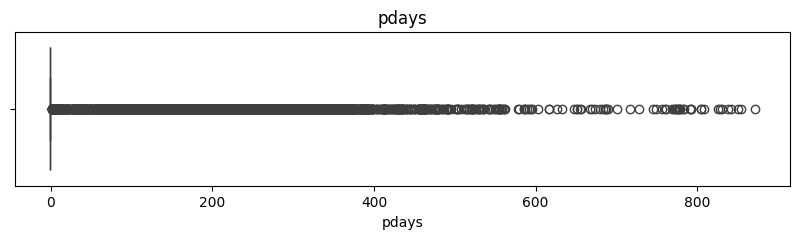

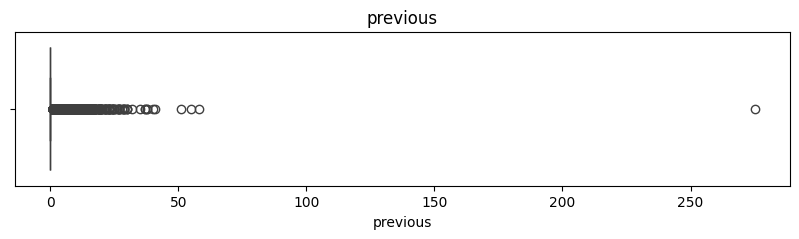

In [80]:
for col in numerical.columns:

    plt.figure(figsize=(10,2))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

### Analisis Outlier

Beberapa fitur numerik menunjukkan adanya nilai ekstrem (outlier).

Keberadaan outlier akan dipertimbangkan pada tahap preprocessing sesuai dengan karakteristik model machine learning yang akan digunakan.

# Kesimpulan Hasil EDA

Berdasarkan hasil Exploratory Data Analysis, diperoleh beberapa informasi penting sebagai berikut:

- Dataset terdiri dari 45.211 observasi dengan 17 atribut.
- Tidak ditemukan missing value pada seluruh kolom.
- Dataset memiliki data duplikat yang akan dihapus pada tahap preprocessing.
- Variabel target memiliki distribusi yang tidak seimbang antara kelas **yes** dan **no**.
- Dataset terdiri dari kombinasi fitur numerik dan kategorikal sehingga diperlukan proses encoding.
- Fitur numerik memiliki rentang nilai yang berbeda sehingga akan dilakukan standarisasi.

Berdasarkan hasil tersebut, tahap preprocessing akan difokuskan pada penghapusan data duplikat, encoding variabel kategorikal, standarisasi fitur numerik, serta pembagian dataset menjadi data latih dan data uji.

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

## 5.1 Membuat Salinan Dataset

Langkah pertama adalah membuat salinan dataset agar data asli tetap terjaga apabila sewaktu-waktu diperlukan kembali.

In [81]:
df_pre = df.copy()

df_pre.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 5.2 Verifikasi Missing Value

Tahap ini dilakukan untuk memastikan kembali bahwa dataset yang akan digunakan pada proses pelatihan model benar-benar tidak memiliki nilai kosong.

In [82]:
missing = df_pre.isnull().sum()

missing

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


### Analisis

Hasil pemeriksaan menunjukkan bahwa seluruh atribut memiliki jumlah missing value sebesar nol sehingga tidak diperlukan proses imputasi.

## 5.3 Verifikasi Data Duplikat

Tahap ini dilakukan untuk memastikan bahwa dataset yang digunakan tidak mengandung observasi yang tercatat lebih dari satu kali.

In [83]:
duplicate = df_pre.duplicated().sum()

print("Jumlah data duplikat :", duplicate)

Jumlah data duplikat : 0


### Analisis

Hasil pemeriksaan menunjukkan bahwa tidak ditemukan data duplikat pada dataset sehingga tidak diperlukan proses penghapusan data.

## 5.4 Encoding Variabel Target

Variabel target (y) masih berupa data kategorikal dengan nilai **yes** dan **no**. Agar dapat diproses oleh algoritma machine learning, variabel target dikonversi menjadi bentuk numerik menggunakan Label Encoding.

In [84]:
le = LabelEncoder()

df_pre["y"] = le.fit_transform(df_pre["y"])

df_pre["y"].value_counts()

,count
y,
0,39922
1,5289


## 5.5 Encoding Fitur Kategorikal

Selain variabel target, dataset juga memiliki beberapa fitur kategorikal seperti pekerjaan, status pernikahan, pendidikan, jenis kontak, dan bulan. Seluruh fitur kategorikal diubah menjadi data numerik menggunakan teknik One-Hot Encoding.

In [85]:
df_pre = pd.get_dummies(
    df_pre,
    drop_first=True
)

df_pre.head()

,age,balance,day,duration,campaign,pdays,previous,y,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,default_yes,housing_yes,loan_yes,contact_telephone,contact_unknown,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,261,1,-1,0,0,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True
1,44,29,5,151,1,-1,0,0,False,False,False,False,False,False,False,False,True,False,False,False,True,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True
2,33,2,5,76,1,-1,0,0,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,True,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True
3,47,1506,5,92,1,-1,0,0,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True
4,33,1,5,198,1,-1,0,0,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True


## 5.6 Memisahkan Fitur dan Target

Dataset dipisahkan menjadi fitur (X) dan target (y) agar dapat digunakan pada proses pelatihan model machine learning.

In [86]:
X = df_pre.drop("y", axis=1)
y = df_pre["y"]

## 5.7 Membagi Data Training dan Testing

Dataset dibagi menjadi data latih (training) dan data uji (testing) menggunakan rasio 80:20. Pembagian dilakukan menggunakan metode stratified sampling agar proporsi kelas target tetap terjaga pada kedua dataset.

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Ukuran X_train :", X_train.shape)
print("Ukuran X_test  :", X_test.shape)
print("Ukuran y_train :", y_train.shape)
print("Ukuran y_test  :", y_test.shape)

Ukuran X_train : (36168, 42)
Ukuran X_test  : (9043, 42)
Ukuran y_train : (36168,)
Ukuran y_test  : (9043,)


### Analisis

Dataset berhasil dibagi menjadi data training sebesar 80% dan data testing sebesar 20%. Pembagian menggunakan stratified sampling memastikan distribusi kelas target tetap seimbang pada kedua kelompok data.

## 5.8 Standarisasi Fitur Numerik

Setelah dataset dibagi menjadi data training dan data testing, langkah selanjutnya adalah melakukan standarisasi pada fitur numerik menggunakan **StandardScaler**.

Standarisasi bertujuan untuk menyamakan skala antar fitur numerik sehingga proses pembelajaran model menjadi lebih optimal. Pada tahap ini, standarisasi hanya diterapkan pada fitur numerik asli, sedangkan fitur hasil One-Hot Encoding tidak distandarisasi karena sudah berupa nilai biner (0 dan 1).

In [88]:
numerical_cols = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

X_test[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

X_train.head()

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,default_yes,housing_yes,loan_yes,contact_telephone,contact_unknown,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
24001,-0.460434,-0.164410,1.582124,-0.457311,-0.246104,-0.410910,-0.241509,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
43409,-1.589641,0.899627,-1.298384,2.502493,0.398202,1.446096,2.664584,False,False,False,False,False,False,False,True,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
20669,0.292371,-0.365486,-0.458236,5.697691,0.398202,-0.410910,-0.241509,False,False,False,False,False,False,False,False,True,False,False,False,True,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
18810,0.668773,-0.445003,1.822166,-0.862499,2.653271,-0.410910,-0.241509,False,False,False,False,False,False,False,False,False,True,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
23130,-0.272233,-0.361249,1.222060,-0.777602,2.331118,-0.410910,-0.241509,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True


### Analisis

Proses standarisasi berhasil dilakukan pada seluruh fitur numerik. Setelah standarisasi, setiap fitur memiliki skala yang lebih seragam sehingga dapat membantu meningkatkan stabilitas dan performa algoritma machine learning yang sensitif terhadap perbedaan skala data.

## 5.9 Menyimpan Dataset Hasil Preprocessing

Tahap terakhir pada preprocessing adalah menyimpan dataset yang telah diproses ke dalam format CSV. Dataset ini akan digunakan kembali pada tahap pembangunan model machine learning dan proses otomatisasi preprocessing tanpa perlu mengulangi seluruh tahapan preprocessing dari awal.

In [89]:
train_preprocessed = X_train.copy()
train_preprocessed["target"] = y_train.values

test_preprocessed = X_test.copy()
test_preprocessed["target"] = y_test.values

train_preprocessed.to_csv(
    "/content/drive/MyDrive/Dicoding_MSML/train_preprocessing.csv",
    index=False
)

test_preprocessed.to_csv(
    "/content/drive/MyDrive/Dicoding_MSML/test_preprocessing.csv",
    index=False
)

print("Dataset preprocessing berhasil disimpan.")

Dataset preprocessing berhasil disimpan.


### Analisis

Dataset hasil preprocessing berhasil disimpan dalam format CSV. Dataset ini siap digunakan pada tahap pembangunan model machine learning (`modelling.py`) serta proses otomatisasi preprocessing (`automate_Mohalfinoor.py`).

# **6. Kesimpulan Preprocessing**

Berdasarkan tahapan preprocessing yang telah dilakukan, dataset berhasil dipersiapkan untuk proses pembangunan model machine learning.

Tahapan preprocessing yang dilakukan meliputi:

- Membuat salinan dataset.
- Memverifikasi tidak adanya missing value.
- Memverifikasi tidak adanya data duplikat.
- Melakukan Label Encoding pada variabel target.
- Melakukan One-Hot Encoding pada fitur kategorikal.
- Memisahkan fitur dan target.
- Membagi dataset menjadi data training dan data testing.
- Melakukan standarisasi pada fitur numerik.
- Menyimpan dataset hasil preprocessing.

Dataset hasil preprocessing selanjutnya akan digunakan pada proses pembangunan model machine learning dan otomatisasi preprocessing pada tahap berikutnya.